(ode:integration-schemes)=
# Integration schemes


Link to [Z-transform](complex:z-transform) for discrete-time signals.


```{dropdown} Contents
:open:

**Schemes.**

* Euler methods, CN
* RK
* Multi-step: AB, AM, BDF,...
* Other methods:
  * Newmark-beta, Verlet (Leapfrog),...

**Concepts.**

* Convergence:
* Consistence:
* Stability:
  * zero-stability
  * A-stability
  * L-stability
* Stiffness

**Theoretical results**

* Dahlquist barriers
* Lax-Richtmyer

**References**

* [Advantage of L-stability compared to A-stability](https://math.stackexchange.com/questions/1466978/advantage-of-l-stability-compared-to-a-stability), Mathematics Stack Exchange.

```

## Concepts

### Local truncation error and Consistency

Let

$$y_{n+1} = \Psi(t_{n+1}; y_n, ..., y_{n-k+1}; h, f(\cdot)) = y_n + h A(t_{n+1}; y_n, ..., y_{n-k+1}; h, f(\cdot)) \ ,$$

the numerical method for the solution of the initial value problem

$$\begin{aligned}
  \dot{y}(t) & = f(y(t),t) \\
  y(0) & = y_0 \ . 
\end{aligned}$$

The **local truncation error** is the error produced by **one step of the method**, i.e.

$$\delta_{n+k}^h := y_{n+k} - y(t_{n+k}) \ ,$$

being $y_{n+k}$ the result of one step of the numerical method, and $y(t_{n+k})$ the exact solution using the same initial conditions (assuming, there's no error in previous steps). A numerical method is defined **consistent** if

$$\lim_{h \rightarrow 0} \frac{\delta^h_{n+k}}{h} = 0 \ .$$

The method has **order** $p$ if 

$$\delta^h_{n+k} = O(h^{p+1}) \quad , \quad \text{for } h \rightarrow 0 \ .$$


### Global truncation error and Convergence

The **global truncation error** $e_n$ is the accumulation of the error up to time $t_n$,

$$e_n^h := y_{n} - y(t_n) \ .$$

A numerical method is defined **convergent** if 

$$\lim_{h \rightarrow 0} \max_n | e_{n} | = 0 \ .$$



#### Recurrence relation for One-step methods

A one-step method reads

$$y_{n+1} = \Psi(t_{n+1}; y_n; h, f(\cdot)) = y_n + h A(t_{n+1}; y_n; h, f(\cdot)) \ ,$$


A recurrence relation exists between the global and the local truncation error

...

*this implies some bound of the global error, see [wiki](https://en.wikipedia.org/wiki/Truncation_error_(numerical_integration))*

### Stability of a linear system

Linear homogeneous equation (or system?)

$$\begin{aligned}
  \dot{y} & = \lambda y \\
  y(0) & = y_0 \ ,
\end{aligned}$$

is a first test for the stability of a numerical method. The problem has the exact solution

$$y(t) = y_0 e^{\lambda t} \ ,$$

and is **asymptotically stable** if $\text{re}\{\lambda\} < 0$, as 

$$\lim_{t \rightarrow +\infty} y(t) = \lim_{t \rightarrow +\infty} y_0 e^{\lambda t} =  \lim_{t \rightarrow +\infty} y_0 e^{\text{re}\{\lambda\} t} e^{j \, \text{im}\{\lambda\} t} \ . $$

Forced linear equation (or system?)

$$\dot{y} = \lambda y + u \ .$$

The exact solution converges to the forced solution if the system is asymptotically stable, For periodic forcing, the behavior can be evaluated in frequency (Laplace or Fourier) domain

$$y(s) = \frac{1}{s - \lambda} u(s) \ .$$

#### A-stability

A-stability ensures the numerical method doesn't explode in the simulation of a asymptotically stable system.

A numerical method is defined A-stable if its stability region includes the whole left half plane.

#### L-stability

Let $z := h \lambda$. For **one-step methods**, it's possible to define a **scalar transfer function** $G(z)$ between $y_{n}$ and $y_{n+1}$,

$$y_{n+1} = G(z) y_n \ .$$

For **multi-step methods**... proerties of characteristic polynomial and its roots

For **systems**... amplification matrix...


L-stability ensures that the method damps extremely fast - **stiff** - modes, that are usually physically irrelevant but that can be numerically troublesome. A method is defined L-stable if

$$\lim_{z \rightarrow -\infty} G(z) = 0 \ .$$



### Some schemes

#### Homogeneous equation

**Explicit Euler.**

$$y_{n+1} = y_{n} + h f(y_n, t_n) = y_n + h \lambda y_n = ( 1 + h \lambda ) y_n \ .$$

The solution of this difference equation with initial condition $y_0$ reads

$$y_{n} = ( 1 + h \lambda )^n y_0 \ .$$

**Implicit Euler.**

$$y_{n+1} = y_{n} + h f(y_{n+1}, t_{n+1}) = y_n + h \lambda y_{n+1} \ .$$

The solution of this difference equation with initial condition $y_0$ reads

$$y_{n} = \frac{1}{( 1 - h \lambda )^n} y_0 \ .$$

**Crank-Nicolson.**

$$y_{n+1} = y_n + \frac{h}{2} \left[ f(y_{n}, t_{n}) + f(y_{n+1}, t_{n+1}) \right] = y_n + \frac{h}{2} \left[ \lambda y_{n} + \lambda y_{n+1} \right] \ .$$

$$y_{n} = \left[ \frac{1 + \lambda h / 2}{1 - \lambda h / 2} \right]^n y_0 \ .$$


#### Forced equation

$$\dot{y} = \lambda y(t) + u(t)$$

**Explicit Euler.**

$$y_{n+1} = y_{n} + h f(y_n, t_n) = y_n + h \lambda y_n = ( 1 + h \lambda ) y_n + h u(t_n) \ .$$

...

**Implicit Euler.**

$$y_{n+1} = y_{n} + h f(y_{n+1}, t_{n+1}) = y_n + h \lambda y_{n+1} + h y(t_n) \ .$$

...

**Crank-Nicolson.**

$$y_{n+1} = y_n + \frac{h}{2} \left[ f(y_{n}, t_{n}) + f(y_{n+1}, t_{n+1}) \right] = y_n + \frac{h}{2} \left[ \lambda y_{n} + \lambda y_{n+1} \right] + \frac{h}{2} \left[ u(t_n) + u(t_{n+1}) \right] \ .$$

...


#### A-stability

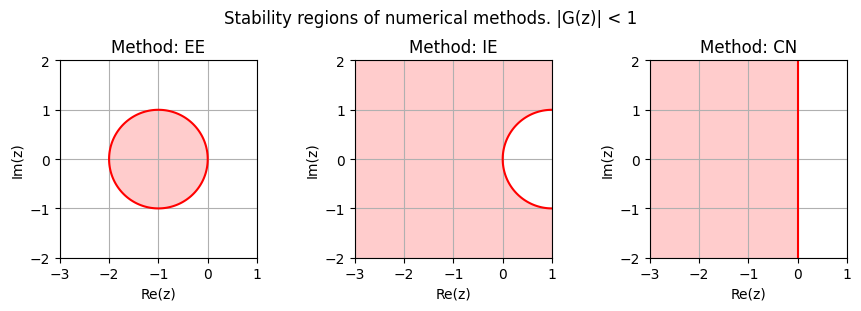

In [17]:
import numpy as np
import matplotlib.pyplot as plt

ampl_fun_ee = lambda z: 1 + z
ampl_fun_ie = lambda z: 1 / ( 1 - z )
ampl_fun_cn = lambda z: ( 1 + z/2 ) / ( 1 - z/2 )

ampl_funs = {
    'EE': ampl_fun_ee, 
    'IE': ampl_fun_ie, 
    'CN': ampl_fun_cn
}
n_methods = len(ampl_funs)

def complex_amplification_fun(ampl_fun):
    x = np.linspace(-3, 1, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y

    return X,Y, ampl_fun(Z)


fig, ax = plt.subplots(1,n_methods, figsize=(n_methods*3, 3))

i_method = 0
for label, fun in ampl_funs.items():

    X, Y, G = complex_amplification_fun(fun)
    ax[i_method].contour(X, Y, np.abs(G), levels=[1.0], colors='r')
    ax[i_method].contourf(X, Y, np.abs(G), levels=[0., 1.0], colors=['#ffcccc'])
    ax[i_method].set_title(f"Method: {label}")
    ax[i_method].set_aspect("equal")
    ax[i_method].set_xlabel(f"Re(z)"); ax[i_method].set_ylabel(f"Im(z)"); ax[i_method].grid()

    i_method += 1

fig.suptitle("Stability regions of numerical methods. |G(z)| < 1")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()

**A-stability.** Implicit Euler and Crank-Nicolson methods are A-stable, while explicit Euler is not.

#### G(z) on the real axis

/tmp/ipykernel_21600/1699983498.py:6: RuntimeWarning: divide by zero encountered in divide
  ampl_fun_cn = lambda z: ( 1 + z/2 ) / ( 1 - z/2 )


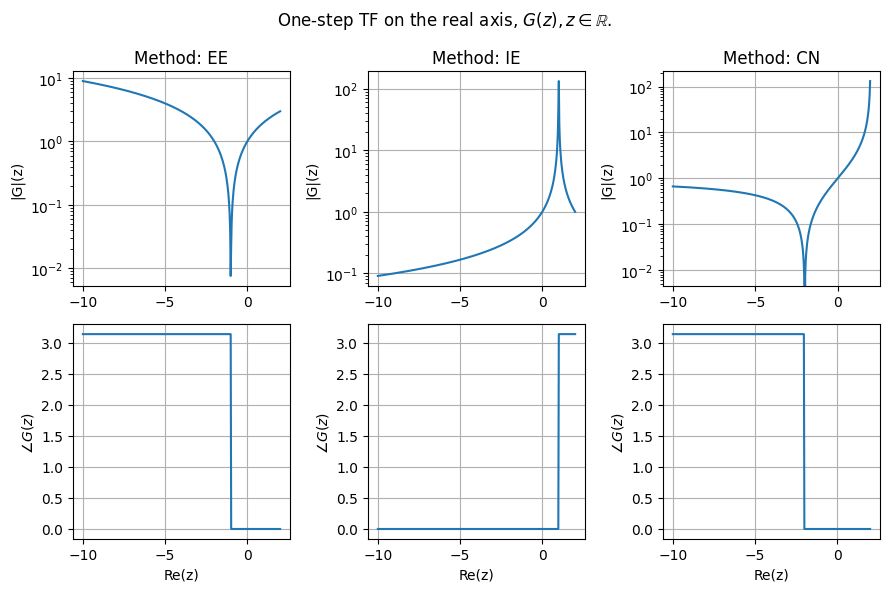

In [39]:
fig, ax = plt.subplots(2,n_methods, figsize=(n_methods*3, 2*3))
i_method = 0

for label, fun in ampl_funs.items():

    x = np.linspace(-10, 2, 400)
    G = fun(x)
    
    ax[0,i_method].plot(x, np.abs(G))
    ax[0,i_method].set_title(f"Method: {label}")
    ax[0,i_method].set_ylabel(f"|G|(z)"); ax[0,i_method].grid()
    ax[0,i_method].set_yscale("log")
    ax[1,i_method].plot(x, np.angle(G))
    ax[1,i_method].set_ylabel(r"$\angle G(z)$"); ax[1,i_method].grid()
    ax[1,i_method].set_xlabel(f"Re(z)"); 

    i_method += 1

fig.suptitle(r"One-step TF on the real axis, $G(z), z \in \mathbb{R}$.")
fig.tight_layout()
plt.show()


#### G(z) on the imaginary axis

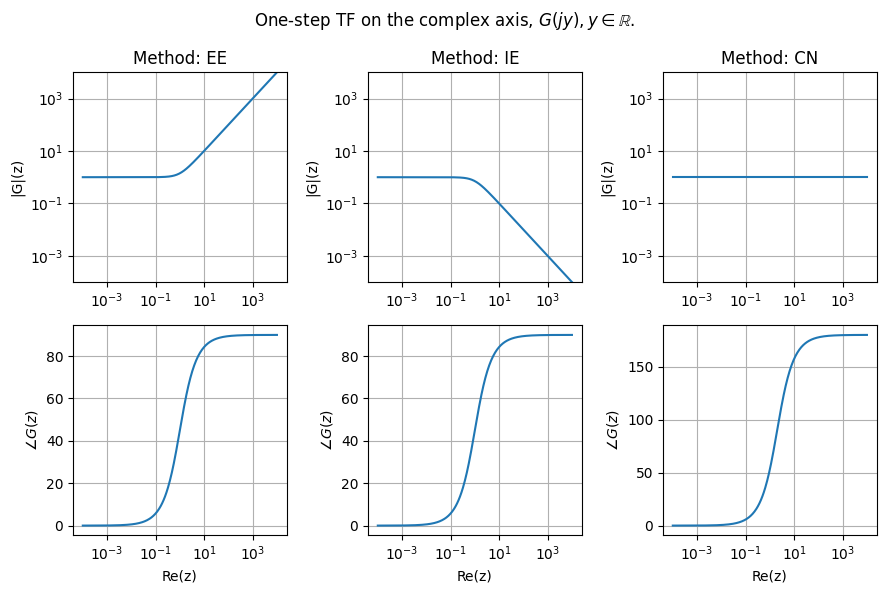

In [47]:
fig, ax = plt.subplots(2,n_methods, figsize=(n_methods*3, 2*3))
i_method = 0


min_absGs, max_absGs = [], []

for label, fun in ampl_funs.items():

    y = np.logspace(-4, 4, 400)
    G = fun(1j * y)

    min_absGs += [ np.min(np.abs(G)) ]
    max_absGs += [ np.max(np.abs(G)) ]
    
    ax[0,i_method].plot(y, np.abs(G))
    ax[0,i_method].set_title(f"Method: {label}")
    ax[0,i_method].set_ylabel(f"|G|(z)"); ax[0,i_method].grid()
    ax[0,i_method].set_yscale("log")
    ax[1,i_method].plot(y, np.angle(G) * 180/np.pi)
    ax[1,i_method].set_ylabel(r"$\angle G(z)$"); ax[1,i_method].grid()
    ax[1,i_method].set_xlabel(f"Re(z)");

    ax[0,i_method].set_xscale("log");  ax[1,i_method].set_xscale("log")

    i_method += 1

min_absG = np.min(min_absGs)
max_absG = np.max(max_absGs)

for i in np.arange(i_method):
    ax[0,i].set_ylim(min_absG, max_absG)


fig.suptitle(r"One-step TF on the complex axis, $G(j y), y \in \mathbb{R}$.")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()